Reference: https://guides.codepath.com/compsci/UMPIRE-Interview-Strategy

## **1. Understand (U - Understand what the instructor is asking for by using test cases and questions about the problem)**

### What is the project asking?

We're tasked with building a **multi-class classifier** that uses **transfer learning** to identify 9 types of waste from images. We're expected to:

* Split images into training, validation, and test sets
* Preprocess and augment images
* Use **pre-trained CNNs** (ResNet50, ResNet100, EfficientNetB0, VGG16)
* Freeze base layers and train new classification heads
* Train for at least 50 epochs, using early stopping
* Evaluate models using **Precision, Recall, F1 Score, AUC**

### Test Cases / Questions:

* Does the input preprocessing pipeline ensure all images are the same shape?
* Are we freezing the base model correctly?
* Is the model learning meaningful class differences, or just overfitting?
* Can it generalize well on unseen waste images?

---

## **2. Match (M - Match what this problem looks like to known categories of problems, e.g. Linked List or Dynamic Programming and strategies or patterns in those categories)**

### What type of problem is this?

This is a **Supervised Multi-class Image Classification** problem using:

* **Transfer Learning**: for better feature extraction from small datasets
* **CNN Architectures**: pre-trained on ImageNet
* **Evaluation via Classification Metrics** (macro/micro/weighted)

### Related strategies:

* **Data augmentation** to combat overfitting
* **Model checkpointing and early stopping** for generalization
* **Softmax + cross-entropy loss** for multi-class output
* **One-hot encoding** for categorical targets
* **Train/val/test split by class** to ensure balance

---

## **3. Plan (P - Plan the solution with appropriate visualizations and pseudocode)**

### Visual Steps:

1. **Load and label data**
   Each folder → one class → label index → one-hot vector

2. **Split data**
   For each class folder:

   * 80% for training
   * 20% for test
   * 20% of training → validation

3. **Resize/preprocess images**
   Resize to 160×160

4. **Augment training data**
   Use zoom, flip, rotate, translate, contrast

5. **Load pre-trained model (frozen)**
   Use `include_top=False`
   Add new head:

   ```
   GlobalAveragePooling2D
   Dense → ReLU
   BatchNorm → Dropout(0.2)
   Dense(9, activation='softmax')
   ```

6. **Compile and Train**

   * `categorical_crossentropy`
   * `Adam`, learning rate tuning
   * batch_size=15
   * 50–100 epochs
   * early stopping on validation loss

7. **Evaluate and Compare**

   * Use sklearn metrics on test set
   * Plot training/val curves
   * Identify best-performing model

### Pseudocode:

```python
for folder in realwaste:
    label = folder_name_to_index[folder]
    for i, img in enumerate(sorted(images_in_folder)):
        image = preprocess(img)
        if i < 0.8 * len(images): train.append((image, label))
        else: test.append((image, label))

augment_train_set()

for model_name in ['ResNet50', 'ResNet100', ...]:
    base_model = load_pretrained(model_name, include_top=False, weights='imagenet')
    freeze_all_layers(base_model)
    head = create_custom_head()
    model = combine(base_model, head)
    compile(model)
    train(model)
    evaluate(model, test_set)
```

---

## **4. Implement (I - Implement the code to solve the algorithm)**

To be conducted

---

## **5. Review (R - Review the code by running specific example(s) and recording values (watchlist) of our code's variables along the way)**

We'll review by:

* Tracking `loss`, `accuracy`, `val_loss`, and `val_accuracy` during training
* Watching example predictions and confusion matrix to check for class confusion
* Logging model performance for each architecture

Tools: `matplotlib`, `sklearn.metrics`, `confusion_matrix`, `classification_report`

---

## **6. Evaluate (E - Evaluate the performance of our algorithm and state any strong/weak or future potential work)**

### Performance Considerations:

* Training time may differ across architectures
* ResNet50 is often a strong baseline; EfficientNetB0 balances speed and performance
* Watch for **overfitting** if val loss diverges from train loss

In [1]:
!pip install tensorflow opencv-python
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50, ResNet101, VGG16, EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
import os

# Update this path to where the file lives in Drive
zip_path = "/content/drive/MyDrive/RealWaste.zip"
extract_path = "/content/RealWaste"

# Only unzip if not already extracted
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("Unzipped successfully to:", extract_path)


Unzipped successfully to: /content/RealWaste


## Data Exploration and Pre-processing

In [4]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Define image size and class names
IMG_SIZE = 160
data_dir = "RealWaste"
class_names = sorted(os.listdir(data_dir))
label_map = {name: idx for idx, name in enumerate(class_names)}
print(label_map)

{'1-Cardboard': 0, '2-Food Organics': 1, '3-Glass': 2, '4-Metal': 3, '5-Miscellaneous Trash': 4, '6-Paper': 5, '7-Plastic': 6, '8-Textile Trash': 7, '9-Vegetation': 8}


In [5]:
# In case all the images do not have the same size, zero-pad or resize the images
# in your dataset. This can be done using various tools, including OpenCV

X = []
y = []

for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    image_files = sorted(os.listdir(class_path))

    for file in image_files:
        img_path = os.path.join(class_path, file)
        try:
            img = cv2.imread(img_path)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img)
            y.append(label_map[class_name])
        except:
            print(f"Skipping unreadable file: {img_path}")

In [6]:
# Images are numbered in each folder. Select the first 80% of the images in
# each folder as your training set and the rest as the test set. You can encode
# your classes using one-hot encoding.

from tensorflow.keras.applications.vgg16 import preprocess_input
X = np.array(X, dtype=np.float32)
X = preprocess_input(X)
y = to_categorical(y, num_classes=9)  # one-hot encode
print(X.shape, y.shape)

# Create non-one-hot label array for stratification
y_labels = np.argmax(y, axis=1)

# 80% train, 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y_labels, random_state=42
)

# Use same strategy to split validation from training
y_train_full_labels = np.argmax(y_train_full, axis=1)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full_labels, random_state=42
)

print("Train:", X_train.shape)
print("Valid:", X_val.shape)
print("Test:", X_test.shape)

(4752, 160, 160, 3) (4752, 9)
Train: (3040, 160, 160, 3)
Valid: (761, 160, 160, 3)
Test: (951, 160, 160, 3)


## Transfer Learning

In [7]:
# In this project, you will use pre-trained models ResNet50, ResNet100,
# EfficientNetB0, and VGG16. For those pre-trained networks, you will only
# train the last fully connected layer, and will freeze all layers before them
# (i.e. we do not change their parameters during training) and use the outputs
# of the penultimate layer in the original pre-trained model as the features
# extracted from each image.
# ------------------------------------------------------------------------------
# Use ReLU activation functions in the last layer and a softmax layer, along
# with L₂ regularization, batch normalization, and a dropout rate of 20% as well
# as ADAM optimizer. Use multinomial cross entropy loss. You can try any batch
# size, but a batch size of 5 seems reasonable.

from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam


def build_model(input_shape=(160, 160, 3), num_classes=9):
    base_model = VGG16(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    # x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model



In [8]:
# To perform empirical regularization, crop, randomly zoom, rotate, flip,
# contrast, and translate images in your training set for image augmentation.
# You can use various tools to do this, including OpenCV.

train_aug = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3]
)


val_aug = ImageDataGenerator()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.2584 - loss: 2.3193

203/203 ━━━━━━━━━━━━━━━━━━━━ 52s 221ms/step - accuracy: 0.2589 - loss: 2.3173 - val_accuracy: 0.5414 - val_loss: 1.3865
Epoch 2/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.5362 - loss: 1.3249

203/203 ━━━━━━━━━━━━━━━━━━━━ 29s 141ms/step - accuracy: 0.5363 - loss: 1.3248 - val_accuracy: 0.6110 - val_loss: 1.1120
Epoch 3/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.5989 - loss: 1.1895

...

203/203 ━━━━━━━━━━━━━━━━━━━━ 30s 147ms/step - accuracy: 0.7085 - loss: 0.8409 - val_accuracy: 0.7240 - val_loss: 0.8001
Epoch 21/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 140ms/step - accuracy: 0.7246 - loss: 0.8153 - val_accuracy: 0.7240 - val_loss: 0.8209
Epoch 22/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 140ms/step - accuracy: 0.7041 - loss: 0.8462 - val_accuracy: 0.7214 - val_loss: 0.8184
Epoch 23/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 140ms/step - accuracy: 0.7194 - loss: 0.8136 - val_accuracy: 0.7293 - val_loss: 0.8060
Epoch 24/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.7101 - loss: 0.8392

203/203 ━━━━━━━━━━━━━━━━━━━━ 29s 142ms/step - accuracy: 0.7101 - loss: 0.8392 - val_accuracy: 0.7411 - val_loss: 0.7945
Epoch 25/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7016 - loss: 0.8237

203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.7016 - loss: 0.8238 - val_accuracy: 0.7398 - val_loss: 0.7880
Epoch 26/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 140ms/step - accuracy: 0.7170 - loss: 0.8084 - val_accuracy: 0.7398 - val_loss: 0.7990
Epoch 27/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 140ms/step - accuracy: 0.6851 - loss: 0.8978 - val_accuracy: 0.7254 - val_loss: 0.8189
Epoch 28/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.7082 - loss: 0.8218

203/203 ━━━━━━━━━━━━━━━━━━━━ 29s 140ms/step - accuracy: 0.7081 - loss: 0.8219 - val_accuracy: 0.7451 - val_loss: 0.7765
Epoch 29/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.7128 - loss: 0.8441 - val_accuracy: 0.7306 - val_loss: 0.7931
Epoch 30/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.7015 - loss: 0.8309 - val_accuracy: 0.7293 - val_loss: 0.8006
Epoch 31/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7057 - loss: 0.8426

203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 140ms/step - accuracy: 0.7057 - loss: 0.8427 - val_accuracy: 0.7438 - val_loss: 0.7564
Epoch 32/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 41s 139ms/step - accuracy: 0.6896 - loss: 0.8679 - val_accuracy: 0.7385 - val_loss: 0.8019
Epoch 33/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.7012 - loss: 0.8888 - val_accuracy: 0.7451 - val_loss: 0.7926
Epoch 34/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.7217 - loss: 0.8205 - val_accuracy: 0.7359 - val_loss: 0.7830
Epoch 35/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 140ms/step - accuracy: 0.6922 - loss: 0.8657 - val_accuracy: 0.7372 - val_loss: 0.7941
Epoch 36/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.7103 - loss: 0.9024 - val_accuracy: 0.7319 - val_loss: 0.7837
Epoch 37/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.6897 - loss: 0.8472 - val_accuracy: 0.7280 - val_loss: 0.8127
Epoch 38/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 41s 138ms/step - accuracy: 0.7276 - loss

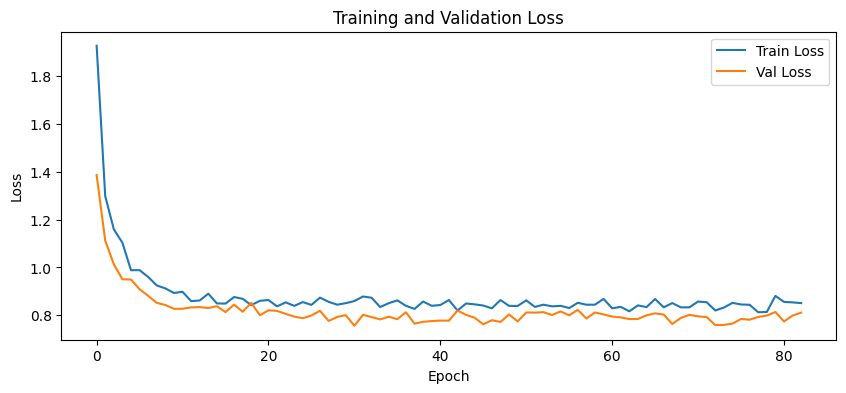

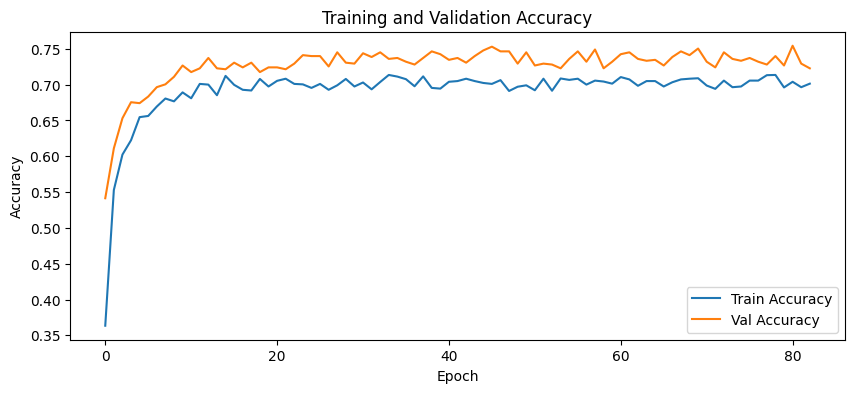

In [9]:
# Train the networks for at least 50 epochs (preferably 100 epochs) and perform
# early stopping using the validation set. Use a randomly selected subset of 20%
# of each class as the validation set. Keep the network parameters that have
# the lowest validation error. Plot the training and validation errors vs. epochs.

from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

# Custom EarlyStopping that only activates after 50 epochs
class DelayedEarlyStopping(EarlyStopping):
    def __init__(self, min_epoch=50, **kwargs):
        super().__init__(**kwargs)
        self.min_epoch = min_epoch

    def on_epoch_end(self, epoch, logs=None):
        if epoch >= self.min_epoch:
            super().on_epoch_end(epoch, logs)
        else:
            # Reset the best weights until min_epoch is reached
            self.wait = 0
            self.stopped_epoch = 0

# Build your model
model = build_model()

# Define callbacks
callbacks = [
    DelayedEarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        min_epoch=50  # Delay early stopping until after epoch 50
    ),
    ModelCheckpoint("best_model_vgg16.h5", save_best_only=True)
]

# Train for up to 100 epochs
history = model.fit(
    train_aug.flow(X_train, y_train, batch_size=15),
    validation_data=val_aug.flow(X_val, y_val),
    epochs=100,                      # Preferable 100 epochs
    callbacks=callbacks
)

# Plot training and validation loss

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Plot accuracy
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [10]:
# Report training, validation, and test Precision, Recall, AUC, and F1 score for
# those models. Is there a model that clearly outperforms others? Remember
# that this is a multi-class classification problem.

# Predict class probabilities and labels
y_pred_probs = model.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_test.argmax(axis=1)

# Classification metrics
print("Classification Report (Test Set):")
print(classification_report(y_true, y_pred, target_names=class_names))

# AUC score
auc_score = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print("AUC Score (macro-average):", auc_score)

30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 328ms/step
Classification Report (Test Set):
                       precision    recall  f1-score   support

          1-Cardboard       0.69      0.83      0.75        92
      2-Food Organics       0.77      0.85      0.81        82
              3-Glass       0.70      0.70      0.70        84
              4-Metal       0.72      0.86      0.78       158
5-Miscellaneous Trash       0.70      0.43      0.54        99
              6-Paper       0.79      0.71      0.75       100
            7-Plastic       0.73      0.70      0.71       185
      8-Textile Trash       0.76      0.69      0.72        64
         9-Vegetation       0.90      0.92      0.91        87

             accuracy                           0.75       951
            macro avg       0.75      0.74      0.74       951
         weighted avg       0.75      0.75      0.74       951

AUC Score (macro-average): 0.9585619677624871
